In [ ]:
#Procedemos con la instalación de los modelos
!pip install xgboost lightgbm
!pip install ipywidgets

## 1. Carga de datos preparados

Partimos de los datasets ya procesados y depurados (`X_entrenamiento_limpio.csv`, `y_entrenamiento_limpio.csv`, `X_futuro_limpio.csv`), generados en el notebook de limpieza a partir de `games.csv`. Estos archivos contienen únicamente variables numéricas, con el suavizado bayesiano ya aplicado sobre el histórico de desarrolladores y editoras, y sin las columnas de texto intermedias (`Developers`, `Publishers`, `developer_clean`, etc.) que ya cumplieron su función en la fase de feature engineering.

In [4]:
import pandas as pd
import numpy as np

x = pd.read_csv("X_entrenamiento_limpio.csv")
y = pd.read_csv("y_entrenamiento_limpio.csv").squeeze("columns")
X_futuro = pd.read_csv("X_futuro_limpio.csv")
nombres_juegos = pd.read_csv("nombres_proximos_juegos.csv").squeeze("columns")
print(x.shape, y.shape, X_futuro.shape)

(100480, 18) (100480,) (1000, 18)


## 2. Partición de datos y escalado

Dividimos el conjunto histórico en entrenamiento (80%) y validación (20%), utilizando muestreo estratificado (`stratify=y`) para preservar la proporción original de las tres clases del target — algo especialmente importante aquí, dado que la Clase 0 (fracaso) representa cerca del 80% del dataset y sin estratificar podríamos obtener una partición de validación poco representativa.

Las variables numéricas continuas se estandarizan con `StandardScaler`, ajustado (`fit`) **únicamente sobre el conjunto de entrenamiento** y aplicado (`transform`) después sobre validación y sobre el conjunto de próximos lanzamientos. Esto es intencional: ajustar el escalador sobre todo el dataset antes de dividirlo introduciría una fuga de información (el modelo "vería" estadísticas del conjunto de validación durante el entrenamiento), lo cual comprometería la validez de las métricas de evaluación.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 


x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
columnas_a_escalar = [
    "Price", "Required age", "num_idiomas", "num_generos", 
    "año_lanzamiento", "mes_lanzamiento", "juegos_publicados_historico", 
    "dev_exito_promedio", "dev_volumen_juegos", 
    "pub_exito_promedio", "pub_volumen_juegos", "tipo_estudio"
]

columnas_a_escalar = [c for c in columnas_a_escalar if c in x_train.columns]


In [16]:

scaler = StandardScaler()
x_train_scaled = x_train.copy()
x_val_scaled = x_val.copy()

x_train_scaled[columnas_a_escalar] = scaler.fit_transform(x_train[columnas_a_escalar])
x_val_scaled[columnas_a_escalar] = scaler.transform(x_val[columnas_a_escalar]) 

X_futuro_scaled = X_futuro.copy()
X_futuro_scaled[columnas_a_escalar] = scaler.transform(X_futuro[columnas_a_escalar])

In [8]:
print(x_train_scaled.dtypes.value_counts())

float64    12
int64       6
Name: count, dtype: int64


## 3. Entrenamiento de modelos

Entrenamos y comparamos cuatro algoritmos de clasificación bajo idénticas condiciones (mismo split, mismo escalado):

- **Random Forest**: ensamble de árboles de decisión por bagging, robusto frente a overfitting y a variables poco informativas.
- **XGBoost**: gradient boosting con regularización, generalmente muy competitivo en datos tabulares.
- **LightGBM**: gradient boosting optimizado para velocidad y eficiencia en memoria, con crecimiento de árboles por hojas (leaf-wise) en vez de por niveles.
- **Regresión Logística**: modelo lineal de referencia (`multi_class='multinomial'`), útil para contrastar si los modelos de árboles realmente aportan valor frente a un enfoque más simple e interpretable.

En todos los casos donde el modelo lo permite, se usa `class_weight='balanced'` para compensar el fuerte desbalance de clases (evitando que el modelo aprenda simplemente a predecir siempre "Fracaso" y aun así obtener una accuracy alta).

In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, random_state=42, objetive="multi:softprob", 
        num_class=3, eval_metric="mlogloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, random_state=42, objective="multiclass", num_class=3
    ),
    "Regresión Logistica": LogisticRegression(
        max_iter=2000, multi_class="multinomial", class_weight="balanced"
    ),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(x_train_scaled, y_train)
    resultados[nombre] = modelo
    print(f"{nombre} entrenado.")

Random Forest entrenado.


C:\Users\adria\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:08:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "objetive" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost entrenado.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1176
[LightGBM] [Info] Number of data points in the train set: 80384, number of used features: 18
[LightGBM] [Info] Start training from score -0.280361
[LightGBM] [Info] Start training from score -1.649983
[LightGBM] [Info] Start training from score -2.948166
LightGBM entrenado.


C:\Users\adria\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Regresión Logistica entrenado.


## 4. Evaluación de modelos

No usamos accuracy como criterio principal de comparación: con un dataset donde el 80% de los casos pertenecen a la Clase 0, un modelo que prediga siempre "Fracaso" obtendría ya un ~80% de accuracy sin haber aprendido nada útil. En su lugar, priorizamos:

- **F1 macro**: promedia el F1-score de las tres clases por igual, penalizando si el modelo ignora las clases minoritarias.
- **ROC-AUC (one-vs-rest, macro)**: mide la capacidad de discriminación del modelo para cada clase frente al resto.
- **Precision/Recall por clase**: especialmente relevantes para la Clase 2 (Gran éxito), la de mayor interés de negocio y la más difícil de predecir por ser minoritaria (~4.3% del dataset).

In [10]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report
)

tabla_metricas = []

for nombre, modelo in resultados.items():
    y_pred = modelo.predict(x_val_scaled)
    y_proba = modelo.predict_proba(x_val_scaled)

    tabla_metricas.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_val, y_pred),
        "F1 macro": f1_score(y_val, y_pred, average="macro"),
        "F1 weighted": f1_score(y_val, y_pred, average="weighted"),
        "Precision macro": precision_score(y_val, y_pred, average="macro"),
        "Recall macro": recall_score(y_val, y_pred, average="macro"),
        "ROC-AUC (ovr, macro)": roc_auc_score(y_val, y_proba, multi_class="ovr", average="macro")
    })

    print(f"\n--- {nombre} ---")
    print(classification_report(y_val, y_pred, target_names=["Fracaso", "Éxito medio", "Gran éxito"]))

df_metricas = pd.DataFrame(tabla_metricas).sort_values("F1 macro", ascending=False)
df_metricas


--- Random Forest ---
              precision    recall  f1-score   support

     Fracaso       0.94      0.96      0.95     15183
 Éxito medio       0.76      0.74      0.75      3860
  Gran éxito       0.83      0.73      0.77      1053

    accuracy                           0.90     20096
   macro avg       0.84      0.81      0.83     20096
weighted avg       0.90      0.90      0.90     20096


--- XGBoost ---
              precision    recall  f1-score   support

     Fracaso       0.95      0.96      0.95     15183
 Éxito medio       0.77      0.75      0.76      3860
  Gran éxito       0.82      0.75      0.79      1053

    accuracy                           0.91     20096
   macro avg       0.85      0.82      0.83     20096
weighted avg       0.91      0.91      0.91     20096


--- LightGBM ---
              precision    recall  f1-score   support

     Fracaso       0.95      0.96      0.95     15183
 Éxito medio       0.78      0.77      0.77      3860
  Gran éxito     

,Modelo,Accuracy,F1 macro,F1 weighted,Precision macro,Recall macro,"ROC-AUC (ovr, macro)"
2,LightGBM,0.910729,0.837783,0.909961,0.855753,0.822033,0.980781
1,XGBoost,0.906499,0.832047,0.905681,0.845653,0.819608,0.979403
0,Random Forest,0.902767,0.825120,0.901818,0.842880,0.809447,0.975650
3,Regresión Logistica,0.864898,0.754867,0.872227,0.716658,0.813904,0.940007


## 5. Importancia de variables

Analizamos qué variables aporta más peso predictivo al modelo ganador (LightGBM), tanto para validar que el modelo aprende patrones con sentido de negocio como para identificar qué variables podrían eliminarse en una futura iteración sin pérdida relevante de rendimiento (por ejemplo, `Windows`, con varianza casi nula en el dataset).

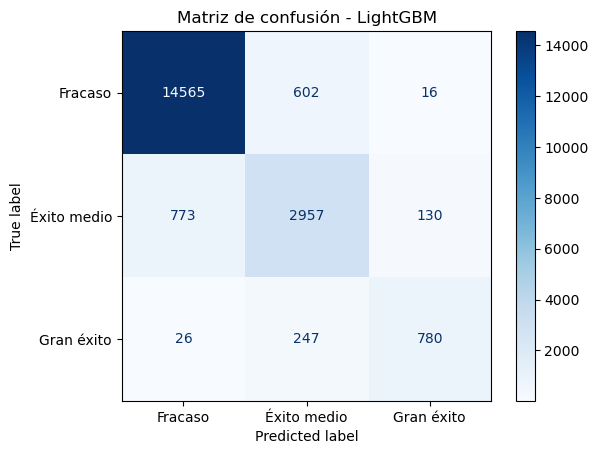

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

mejor_modelo = resultados["LightGBM"]
etiquetas = ["Fracaso", "Éxito medio", "Gran éxito"]

ConfusionMatrixDisplay.from_estimator(
    mejor_modelo, x_val_scaled, y_val, display_labels=etiquetas, cmap="Blues"
)
plt.title("Matriz de confusión - LightGBM")
plt.show()
    

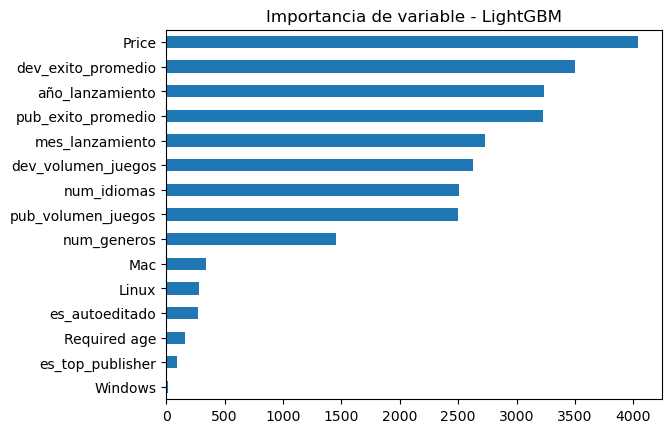

In [12]:
importancias = pd.Series(mejor_modelo.feature_importances_, index=x_train_scaled.columns)
importancias.sort_values(ascending=False).head(15).plot(kind="barh")
plt.title("Importancia de variable - LightGBM")
plt.gca().invert_yaxis()
plt.show()

## 6. Predicciones sobre próximos lanzamientos

Aplicamos el modelo ganador (LightGBM) sobre `X_futuro_scaled`, el conjunto de 1.000 próximos lanzamientos de Steam, obteniendo tanto la clase predicha como la probabilidad asociada a cada una de las tres categorías de éxito.

**Nota importante:** se detectó que aproximadamente un 44% de estos registros comparten un vector de características idéntico (típicamente títulos de estudios sin historial previo que además coinciden en precio, plataformas y fecha de lanzamiento), por lo que el modelo les asigna la misma probabilidad pese a tratarse de juegos distintos. Esta es una limitación conocida del enfoque actual, discutida en la sección 3.5 del informe.

In [13]:
#Comprobamos los datos contenidos en los datasets

X = pd.read_csv("X_entrenamiento_limpio.csv")
y = pd.read_csv("y_entrenamiento_limpio.csv").squeeze("columns")  # para que sea Serie, no DataFrame de una columna
X_futuro = pd.read_csv("X_futuro_limpio.csv")
nombres_juegos = pd.read_csv("nombres_proximos_juegos.csv").squeeze("columns")

print(X.shape, y.shape, X_futuro.shape)
print(X.select_dtypes(include='object').columns.tolist())  # debería salir vacío

(100480, 18) (100480,) (1000, 18)
[]


In [18]:
mejor_modelo = resultados["LightGBM"]

proba_clases = mejor_modelo.predict_proba(X_futuro_scaled)
pred_clase = mejor_modelo.predict(X_futuro_scaled)

resultado_pred = pd.DataFrame({
    "Name": nombres_juegos,
    "prediccion_exito": pred_clase,
    "prob_fracaso": proba_clases[:, 1],
    "prob_exito_medio": proba_clases[:,1],
    "prob_gran_exito": proba_clases[:,2],
})

etiquetas_texto = {0: "Fracaso", 1: "Éxito medio", 2: "Gran éxito"}
resultado_pred["prediccion_texto"] = resultado_pred["prediccion_exito"].map(etiquetas_texto)

resultado_pred.sort_values("prob_gran_exito", ascending=False).head(20)

,Name,prediccion_exito,prob_fracaso,prob_exito_medio,prob_gran_exito,prediccion_texto
363,Go West Together,2,0.000487,0.000487,0.979198,Gran éxito
772,Architects of the Universe: The Orbital Wars,2,0.000279,0.000279,0.975704,Gran éxito
288,Choppa: Rescue Rivals,2,0.000995,0.000995,0.960002,Gran éxito
176,Brigador Killers,2,0.000446,0.000446,0.959890,Gran éxito
263,Vape Store Miami,2,0.000446,0.000446,0.959890,Gran éxito
5,Mortal Shell II,2,0.000510,0.000510,0.924048,Gran éxito
882,BLACKWOOD,2,0.000439,0.000439,0.906363,Gran éxito
3,Hell Let Loose: Vietnam,2,0.001298,0.001298,0.891486,Gran éxito
246,Entropy,2,0.002102,0.002102,0.783538,Gran éxito
43,Aliens: Fireteam Elite 2,2,0.000516,0.000516,0.728964,Gran éxito


In [19]:
# 1. ¿Suman 1 las probabilidades?
suma_probas = proba_clases.sum(axis=1)
print(suma_probas.min(), suma_probas.max())  

# 2. ¿Hay filas duplicadas en X_futuro?
print(X_futuro.duplicated().sum())

# 3. Verifica el orden de clases del modelo
print(mejor_modelo.classes_)  # debería ser [0, 1, 2]

0.9999999999999998 1.0000000000000002
440
[0 1 2]


## 7. Interfaz de predicción interactiva

Para permitir evaluar escenarios hipotéticos sin modificar el código, implementamos una interfaz ligera con `ipywidgets` directamente en el notebook. El usuario introduce las características de un juego mediante controles interactivos y obtiene al instante la predicción del modelo junto con la probabilidad de cada clase.

In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Widgets de entrada, uno por cada variable relevante
w_price = widgets.FloatText(description='Precio (€):', value=19.99)
w_required_age = widgets.IntSlider(description='Edad mínima:', min=0, max=18, value=0)
w_windows = widgets.Checkbox(description='Windows', value=True)
w_mac = widgets.Checkbox(description='Mac', value=False)
w_linux = widgets.Checkbox(description='Linux', value=False)
w_num_idiomas = widgets.IntSlider(description='Nº idiomas:', min=1, max=30, value=5)
w_num_generos = widgets.IntSlider(description='Nº géneros:', min=1, max=8, value=2)
w_año = widgets.IntText(description='Año lanz.:', value=2026)
w_mes = widgets.IntSlider(description='Mes lanz.:', min=1, max=12, value=6)
w_navidad = widgets.Checkbox(description='Lanz. en navidad', value=False)
w_tipo_estudio = widgets.Dropdown(description='Tipo estudio:', options=[('Indie', 0), ('AA', 1), ('AAA', 2)], value=0)
w_dev_exito = widgets.FloatSlider(description='Éxito medio dev:', min=0, max=2, step=0.01, value=float(y.mean()))
w_dev_volumen = widgets.IntText(description='Juegos dev:', value=0)
w_pub_exito = widgets.FloatSlider(description='Éxito medio pub:', min=0, max=2, step=0.01, value=float(y.mean()))
w_pub_volumen = widgets.IntText(description='Juegos pub:', value=0)
w_juegos_hist = widgets.IntText(description='Juegos históricos dev:', value=0)
w_autoeditado = widgets.Checkbox(description='Autoeditado', value=True)
w_top_publisher = widgets.Checkbox(description='Top publisher', value=False)

boton_predecir = widgets.Button(description='Predecir éxito', button_style='success')
salida = widgets.Output()

def predecir_juego(b):
    with salida:
        clear_output()
        entrada = pd.DataFrame([{
            'Required age': w_required_age.value,
            'Price': w_price.value,
            'Windows': int(w_windows.value),
            'Mac': int(w_mac.value),
            'Linux': int(w_linux.value),
            'num_idiomas': w_num_idiomas.value,
            'num_generos': w_num_generos.value,
            'año_lanzamiento': w_año.value,
            'mes_lanzamiento': w_mes.value,
            'lanzamiento_navidad': int(w_navidad.value),
            'juegos_publicados_historico': w_juegos_hist.value,
            'tipo_estudio': w_tipo_estudio.value,
            'dev_exito_promedio': w_dev_exito.value,
            'dev_volumen_juegos': w_dev_volumen.value,
            'pub_exito_promedio': w_pub_exito.value,
            'pub_volumen_juegos': w_pub_volumen.value,
            'es_autoeditado': int(w_autoeditado.value),
            'es_top_publisher': int(w_top_publisher.value),
        }])[x_train.columns]  # mismo orden que en el entrenamiento

        entrada_scaled = entrada.copy()
        entrada_scaled[columnas_a_escalar] = scaler.transform(entrada[columnas_a_escalar])

        proba = mejor_modelo.predict_proba(entrada_scaled)[0]
        pred = mejor_modelo.predict(entrada_scaled)[0]
        etiquetas = ['Fracaso', 'Éxito medio', 'Gran éxito']

        print(f"Predicción: {etiquetas[pred]}\n")
        for et, p in zip(etiquetas, proba):
            print(f"  {et}: {p*100:.1f}%")

boton_predecir.on_click(predecir_juego)

display(widgets.VBox([
    w_price, w_required_age, w_windows, w_mac, w_linux,
    w_num_idiomas, w_num_generos, w_año, w_mes, w_navidad,
    w_tipo_estudio, w_dev_exito, w_dev_volumen, w_pub_exito, w_pub_volumen,
    w_juegos_hist, w_autoeditado, w_top_publisher,
    boton_predecir, salida
]))

In [22]:
# Guardamos el modelo

import joblib
joblib.dump(mejor_modelo, "modelo_lightgbm_steam_success.pkl")
joblib.dump(scaler, "scaler_steam_success.pkl")

['scaler_steam_success.pkl']